# Entrenamiento y Evaluación de Modelos



In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from preprocesamiento import preprocesar_datos
from entrenamiento_utils import ejecutar_entrenamiento_y_evaluacion

import warnings
warnings.filterwarnings('ignore')

## 1. Carga y Preprocesamiento del Dataset

In [2]:
print("Cargando dataset crudo...")
df_crudo = pd.read_csv('data/processed/dataset_crudo_sipa.csv')

print("Ejecutando pipeline de preprocesamiento...")
resultado_preproc = preprocesar_datos(df_crudo)

df_final = resultado_preproc['dataset_final']
encoders = resultado_preproc['encoders']
le_producto = resultado_preproc.get('le_producto')
le_provincia = resultado_preproc.get('le_provincia')

print(f"\nRegistros preprocesados disponibles: {len(df_final)}")

Cargando dataset crudo...
Ejecutando pipeline de preprocesamiento...

Registros preprocesados disponibles: 50862


## 2. Entrenamiento de Modelos



In [3]:
print("Iniciando entrenamiento y evaluación (Fase 2)... esto puede tardar un momento.")
res_entrenamiento = ejecutar_entrenamiento_y_evaluacion(
    df_final=df_final,
    le_producto=le_producto,
    le_provincia=le_provincia,
    encoders=encoders
)

print(f"\nResumen de limpieza temporal:")
print(f"  Filas antes:       {res_entrenamiento['filas_antes']}")
print(f"  Filas eliminadas:  {res_entrenamiento['filas_eliminadas']}")
print(f"  Filas disponibles: {res_entrenamiento['filas_despues']}")

print(f"\n>> MODELO SELECCIONADO COMO GANADOR: {res_entrenamiento['mejor_nombre']}")

Iniciando entrenamiento y evaluación (Fase 2)... esto puede tardar un momento.

Resumen de limpieza temporal:
  Filas antes:       50862
  Filas eliminadas:  588
  Filas disponibles: 50274

>> MODELO SELECCIONADO COMO GANADOR: XGBoost


## 3. Análisis Cuantitativo y Cualitativo

In [4]:
# Tabla comparativa de métricas
tabla = res_entrenamiento['tabla_comparativa']
print('=== MODELOS CANDIDATOS ===\n')
print(tabla.to_string(index=False))

=== MODELOS CANDIDATOS ===

             Modelo  F1-Score (Macro)  Accuracy  Precision (Macro)  Recall (Macro)  Falsos (último fold) Cumple Criterios
      Random Forest            0.6766    0.7394             0.6623          0.7232                  2668               NO
            XGBoost            0.7083    0.7744             0.6918          0.7344                  2272               SI
      Decision Tree            0.6152    0.6923             0.6110          0.6546                  3113               NO
Logistic Regression            0.5976    0.7009             0.5933          0.6029                  3054               NO
                KNN            0.5245    0.6925             0.5932          0.5032                  3142               NO
               LSTM            0.6327    0.7028             0.6236          0.6745                  2988               NO


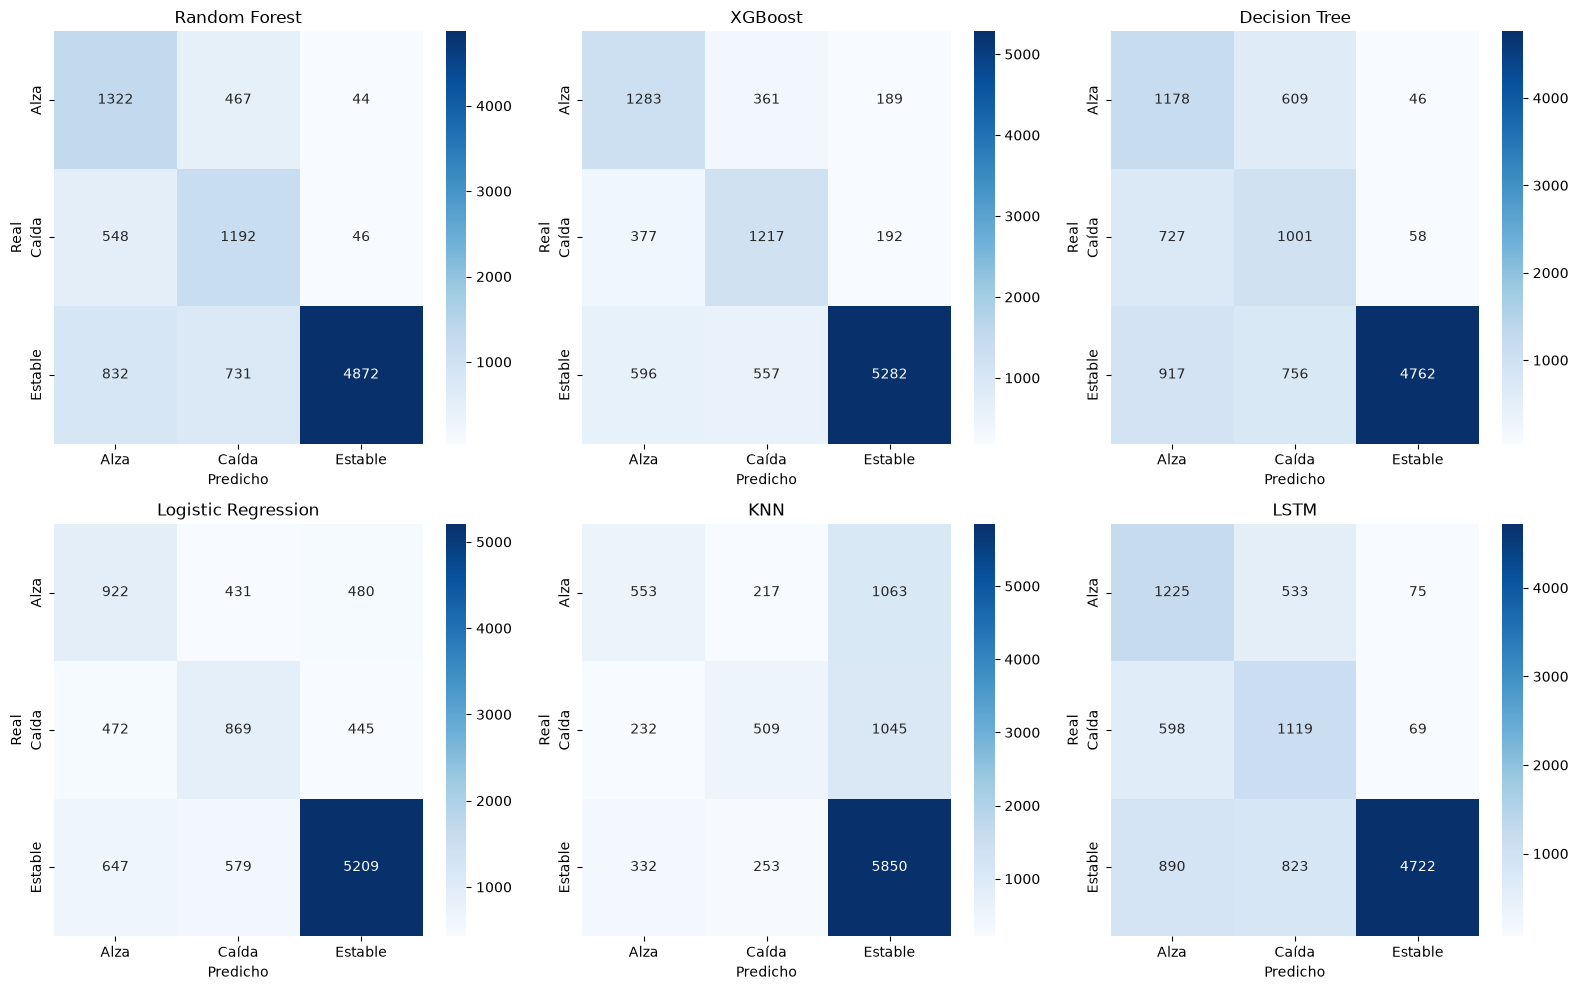

In [5]:
# Matrices de confusión (del último fold)
resultados_modelos = res_entrenamiento['resultados']
clases = res_entrenamiento['classes']

n_modelos = len(resultados_modelos)
n_cols = 3
n_rows = (n_modelos + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten() if n_modelos > 1 else [axes]

for idx, (nombre, res) in enumerate(resultados_modelos.items()):
    cm = res['matriz_confusion']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=clases, yticklabels=clases)
    axes[idx].set_title(f'{nombre}')
    axes[idx].set_xlabel('Predicho')
    axes[idx].set_ylabel('Real')

# Ocultar ejes sobrantes
for idx in range(n_modelos, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Importancia de Variables (Feature Importances)

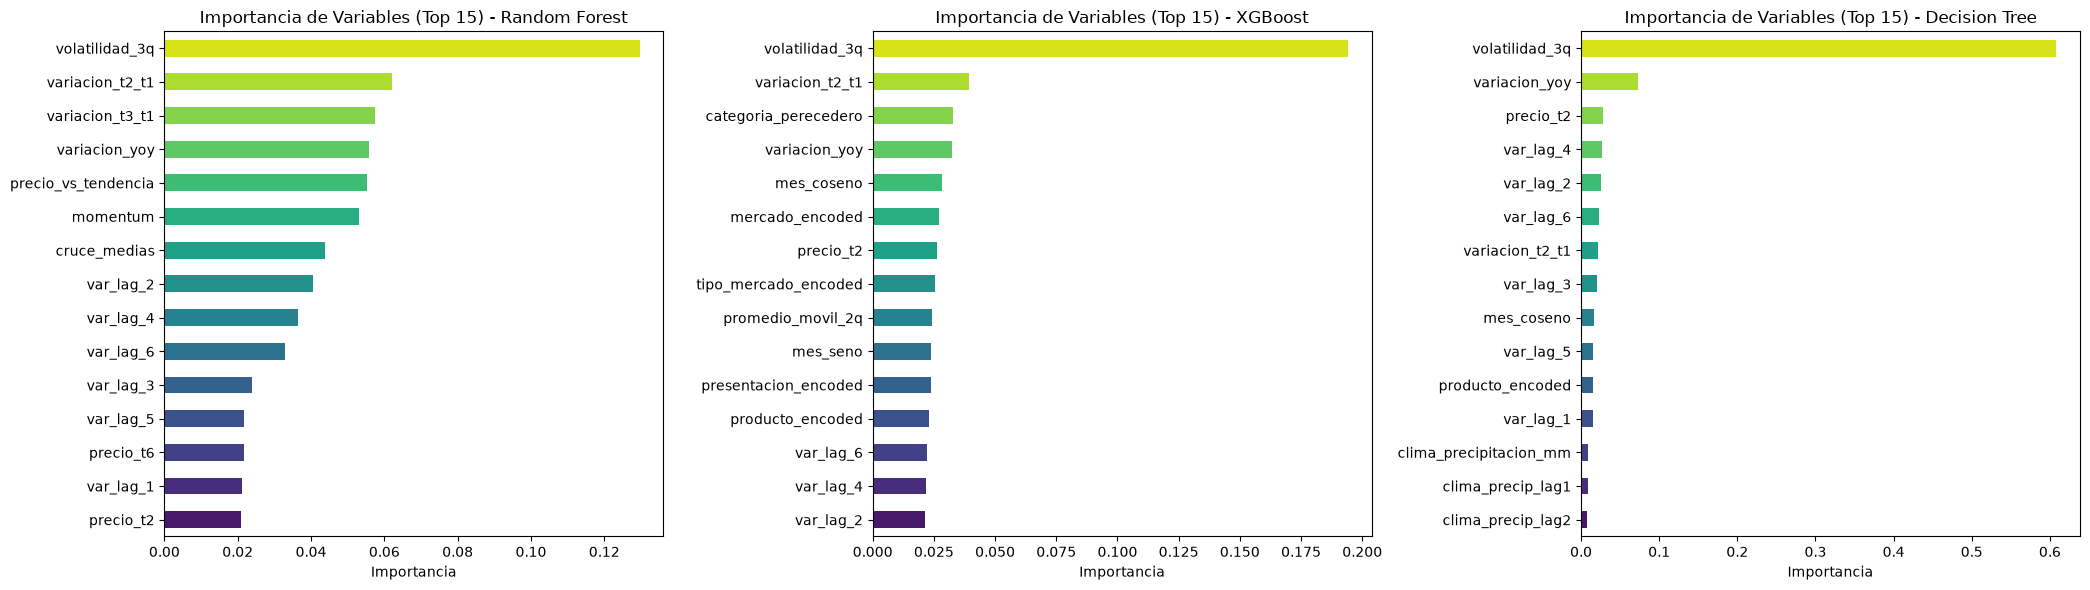

In [6]:
# 1. Recuperamos las features base (31) y agregamos dinámicamente los 6 lags temporales
features_base = res_entrenamiento['features']
lags_cols = [f"var_lag_{i}" for i in range(1, 7)]
features_completos = features_base + lags_cols

# 2. Obtenemos los modelos que soportan feature_importances
modelos_con_importancia = {k: v for k, v in resultados_modelos.items() if v.get('feature_importances') is not None}
n_imp = len(modelos_con_importancia)

if n_imp > 0:
    fig, axes = plt.subplots(1, n_imp, figsize=(7 * n_imp, 6))
    axes = axes if n_imp > 1 else [axes]
    
    for idx, (nombre, res) in enumerate(modelos_con_importancia.items()):
        # ¡Aquí está la clave! Usamos features_completos
        importancias = pd.Series(res['feature_importances'], index=features_completos).sort_values(ascending=True)
        
        # Se plotea solo el Top 15 para facilitar la visualización
        importancias.tail(15).plot(kind='barh', ax=axes[idx], color=sns.color_palette('viridis', 15))
        axes[idx].set_title(f'Importancia de Variables (Top 15) - {nombre}')
        axes[idx].set_xlabel('Importancia')
        
    plt.tight_layout()
    plt.show()
else:
    print('Ningún modelo tiene feature_importances_ disponible.')

## 5. Artefactos Generados


In [7]:
models_dir = res_entrenamiento['models_dir']
print(f'Artefactos guardados automáticamente por el pipeline en {models_dir}/:')

if os.path.exists(models_dir):
    for f in sorted(os.listdir(models_dir)):
        size = os.path.getsize(os.path.join(models_dir, f))
        print(f'  {f} ({size:,} bytes)')
else:
    print("Directorio de modelos no encontrado.")

Artefactos guardados automáticamente por el pipeline en c:\Users\edu-g\Documents\GitHub\Clasificador-Precios-SIPA\data\models/:
  features.pkl (552 bytes)
  le_canton.pkl (466 bytes)
  le_mercado.pkl (627 bytes)
  le_presentacion.pkl (533 bytes)
  le_producto.pkl (1,930 bytes)
  le_provincia.pkl (429 bytes)
  le_target.pkl (498 bytes)
  le_tipo_mercado.pkl (256 bytes)
  mejor_modelo.pkl (19,991,421 bytes)
  scaler.pkl (1,503 bytes)
